Variance and Correlation

In [2]:
!pip install pandas

   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
    --------------------------------------- 0.3/11.4 MB ? eta -:--:--
    --------------------------------------- 0.3/11.4 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.4 MB 728.2 kB/s eta 0:00:15
   -- ------------------------------------- 0.8/11.4 MB 780.2 kB/s eta 0:00:14
   --- ------------------------------------ 1.0/11.4 MB 811.6 kB/s eta 0:00:13
   ---- ----------------------------------- 1.3/11.4 MB 906.3 kB/s eta 0:00:12
   ----- ---------------------------------- 1.6/11.4 MB 975.2 kB/s eta 0:00:11
   ------ --------------------------------- 1.8/11.4 MB 986.7 kB/s eta 0:00:10
   ------- -------------------------------- 2.1/11.4 MB 1.0 MB/s eta 0:00:10
   ------- -------------------------------- 2.1/11.4 MB 1.0 MB/s eta 0:00:10
   -------- ----------

In [19]:
import pandas as pd

data = pd.DataFrame({
    'Math': [70, 60, 40, 80, 30],
    'Chemistry': [60, 80, 65, 55, 60],
    'Physics': [50, 50, 50 , 50 , 50],
    'General_Test': [70, 70, 60, 60, 80],
    'Maths': [70, 60, 40, 80, 30]
})

print(data)

   Math  Chemistry  Physics  General_Test  Maths
0    70         60       50            70     70
1    60         80       50            70     60
2    40         65       50            60     40
3    80         55       50            60     80
4    30         60       50            80     30


In [20]:
!pip install scikit-learn

In [21]:
# Variance
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.0)
selected_features = selector.fit_transform(data)
print(selected_features)

[[70 60 70 70]
 [60 80 70 60]
 [40 65 60 40]
 [80 55 60 80]
 [30 60 80 30]]


In [22]:
data = pd.DataFrame(selected_features, columns=selector.get_feature_names_out())
data

,Math,Chemistry,General_Test,Maths
0,70,60,70,70
1,60,80,70,60
2,40,65,60,40
3,80,55,60,80
4,30,60,80,30


In [23]:
!pip install seaborn

In [24]:
# Correlation
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
cor = data.corr()
cor

,Math,Chemistry,General_Test,Maths
Math,1.000000,-0.150424,-0.489932,1.000000
Chemistry,-0.150424,1.000000,0.124274,-0.150424
General_Test,-0.489932,0.124274,1.000000,-0.489932
Maths,1.000000,-0.150424,-0.489932,1.000000


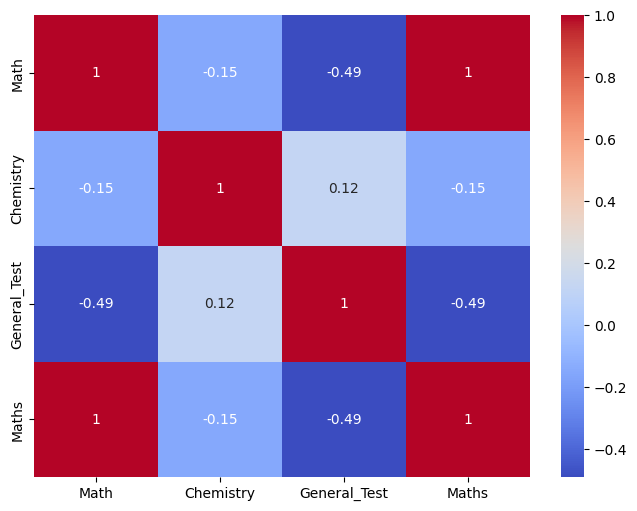

In [26]:
plt.figure(figsize=(8, 6))
sns.heatmap(cor, annot=True, cmap='coolwarm')
plt.show()

In [27]:
corr_features = set()
for i in range(len(cor.columns)):
    for j in range(i):
        if abs(cor.iloc[i, j]) > 0.8:
            colname = cor.columns[i]
            corr_features.add(colname)

In [28]:
corr_features

{'Maths'}

In [29]:
data.drop(corr_features, axis=1)

,Math,Chemistry,General_Test
0,70,60,70
1,60,80,70
2,40,65,60
3,80,55,60
4,30,60,80
